# Notebook 3: Generalization Study

This notebook targets the key research question behind RepE-style probing: **if I train a truthfulness probe on one dataset, does it transfer to different datasets?**

That transfer behavior is important for lie-detection claims. A probe that only works in-distribution is weaker evidence than a probe that keeps signal on new domains.

Here we include the RepE truthful dataset alongside the toy datasets to test transfer more realistically in a local setup.

In [1]:
from pathlib import Path
import sys

# Import the local package directly from src/.
project_root = Path.cwd().parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lie_detector_llm.datasets import build_dataset_collection
from lie_detector_llm.experiment import run_transfer_experiment
from lie_detector_llm.plotting import plot_transfer_results

# Load all datasets including the RepE truthful split.
collection = build_dataset_collection(include_repeng_truthful=True)

# List datasets available for transfer.
collection.dataset_names()

['cities', 'larger_than', 'qa', 'repeng_truthful']

## Run one transfer experiment

I train the probe on `repeng_truthful`, then evaluate it on four targets:

- `repeng_truthful` for in-distribution performance
- `cities` and `qa` for factual transfer
- `larger_than` for transfer to a different reasoning style

This gives a compact transfer matrix that is easy to discuss in a project report.

In [2]:
import io
from contextlib import redirect_stderr, redirect_stdout

# Train on repeng_truthful and evaluate transfer to the other datasets.
# Redirecting stdout/stderr keeps the notebook output focused on the final table.
with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    results = run_transfer_experiment(
        collection=collection,
        train_dataset_name='repeng_truthful',
        eval_dataset_names=['repeng_truthful', 'cities', 'larger_than', 'qa'],
        model_name='distilgpt2',
        probe_method='lr',
        layer_index=-1,
    )

# Summarize grouped accuracy for each evaluation dataset.
results.summary_table()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

,train_dataset,eval_dataset,probe_method,model_name,layer_index,grouped_accuracy
0,repeng_truthful,repeng_truthful,lr,distilgpt2,-1,0.925
1,repeng_truthful,cities,lr,distilgpt2,-1,0.000
2,repeng_truthful,larger_than,lr,distilgpt2,-1,0.300
3,repeng_truthful,qa,lr,distilgpt2,-1,0.250


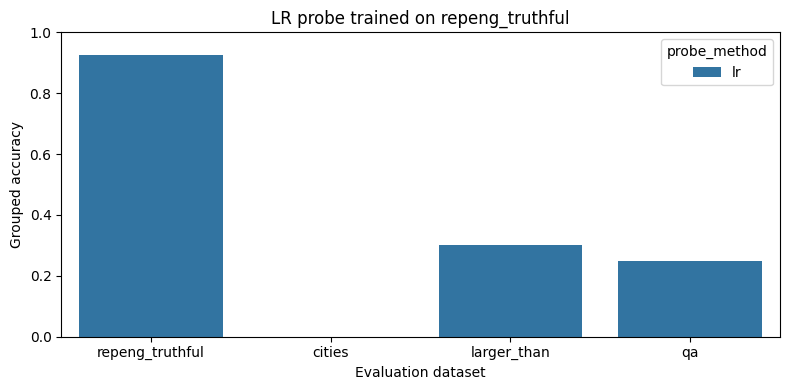

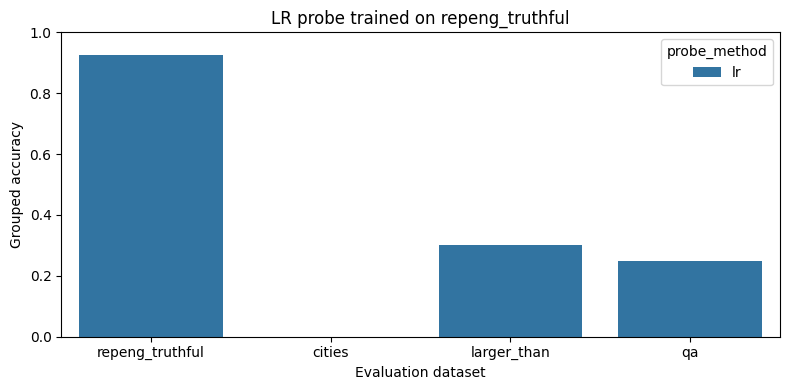

In [3]:
# Turn the transfer table into a simple figure.
figure, axis = plot_transfer_results(
    results.summary_table(),
    title='LR probe trained on repeng_truthful',
)
figure

In [4]:
import io
import pandas as pd
from contextlib import redirect_stderr, redirect_stdout

# Compare several probe families on the same transfer setup.
comparison_tables = []
for probe_method in ['dim', 'lr', 'pca-g', 'lat']:
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        probe_results = run_transfer_experiment(
            collection=collection,
            train_dataset_name='repeng_truthful',
            eval_dataset_names=['repeng_truthful', 'cities', 'larger_than', 'qa'],
            model_name='distilgpt2',
            probe_method=probe_method,
            layer_index=-1,
        )
    comparison_tables.append(probe_results.summary_table())

# Stack results into one dataframe for direct comparison.
comparison_df = pd.concat(comparison_tables, ignore_index=True)
comparison_df

,train_dataset,eval_dataset,probe_method,model_name,layer_index,grouped_accuracy
0,repeng_truthful,repeng_truthful,dim,distilgpt2,-1,0.725
1,repeng_truthful,cities,dim,distilgpt2,-1,0.000
2,repeng_truthful,larger_than,dim,distilgpt2,-1,0.700
3,repeng_truthful,qa,dim,distilgpt2,-1,0.125
4,repeng_truthful,repeng_truthful,lr,distilgpt2,-1,0.925
5,repeng_truthful,cities,lr,distilgpt2,-1,0.000
6,repeng_truthful,larger_than,lr,distilgpt2,-1,0.300
7,repeng_truthful,qa,lr,distilgpt2,-1,0.250
8,repeng_truthful,repeng_truthful,pca-g,distilgpt2,-1,0.550
9,repeng_truthful,cities,pca-g,distilgpt2,-1,0.200


## Natural next steps

If I wanted to push this project closer to the original `repeng` results, the next things to do would be:

1. compare the probe families more systematically
2. sweep several layers instead of using only the last one
3. try a stronger causal model from Hugging Face
4. add a dataset where the model is explicitly prompted to lie

That last point would move the project from general truthfulness probing toward a more direct lie-detection setting.

In [5]:
print('Main transfer table:')
print(results.summary_table().to_string(index=False))

print('\nProbe comparison table:')
print(comparison_df.to_string(index=False))

Main transfer table:
  train_dataset    eval_dataset probe_method model_name  layer_index  grouped_accuracy
repeng_truthful repeng_truthful           lr distilgpt2           -1             0.925
repeng_truthful          cities           lr distilgpt2           -1             0.000
repeng_truthful     larger_than           lr distilgpt2           -1             0.300
repeng_truthful              qa           lr distilgpt2           -1             0.250

Probe comparison table:
  train_dataset    eval_dataset probe_method model_name  layer_index  grouped_accuracy
repeng_truthful repeng_truthful          dim distilgpt2           -1             0.725
repeng_truthful          cities          dim distilgpt2           -1             0.000
repeng_truthful     larger_than          dim distilgpt2           -1             0.700
repeng_truthful              qa          dim distilgpt2           -1             0.125
repeng_truthful repeng_truthful           lr distilgpt2           -1             0.9

## Compact report outputs

Two plain-text tables are printed below:

- Transfer performance for the main LR setup
- Multi-probe comparison on the same transfer matrix